## Regime Detection in Financial Markets using Machine Learning (Data Download — Nikkei 225)
- Author: Abbinav Sankar Kailasam (UCL)
- Supervisors: Dr. Blaz Zlicar (ADIA), Prof. Fabio Caccioli (UCL)

In [16]:
# Standard library, HTTP, and data/finance imports.
from io import StringIO

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from plot_style import set_publication_style, style_axis, format_date_axis, NEUTRAL_COLOURS

set_publication_style()

In [17]:
# Global date range and batch size for the download.
START_DATE  = "2001-01-01"
END_DATE    = "2026-07-15"
BATCH_SIZE  = 50

In [18]:
# Per-index scrape/ticker-map configuration consumed by fetch_constituents.
INDICES = {
    "Nikkei225": {
        "name": "Nikkei 225",
        "source_url": "https://indexes.nikkei.co.jp/en/nkave/index/component",
        "snapshot": "2026-07-21",
        "suffix": ".T",
        "components": {
            "PHARMA": ["4151", "4502", "4503", "4506", "4507", "4519", "4523", "4568", "4578"],
            "ELECMC": ["285A", "4062", "6479", "6501", "6503", "6504", "6506", "6526", "6645",
                       "6701", "6702", "6723", "6724", "6752", "6753", "6758", "6762", "6770",
                       "6841", "6857", "6861", "6902", "6920", "6954", "6963", "6971", "6976",
                       "6981", "7735", "7751", "7752", "8035"],
            "AUTO":   ["543A", "7201", "7202", "7203", "7211", "7261", "7267", "7269", "7270",
                       "7272"],
            "PRECIS": ["4543", "4902", "6146", "7731", "7733", "7741"],
            "COMMS":  ["9432", "9433", "9434", "9984"],
            "BANK":   ["5831", "7186", "8304", "8306", "8308", "8309", "8316", "8331", "8354",
                       "8411"],
            "OTHFIN": ["8253", "8591", "8697"],
            "SECUR":  ["8601", "8604"],
            "INSUR":  ["8630", "8725", "8750", "8766", "8795"],
            "FISH":   ["1332"],
            "FOODS":  ["2002", "2269", "2282", "2501", "2502", "2503", "2801", "2802", "2871",
                       "2914"],
            "RETAIL": ["3086", "3092", "3099", "3382", "7453", "7532", "8233", "8252", "8267",
                       "9843", "9983"],
            "SERVIC": ["2413", "2432", "3659", "3697", "4307", "4324", "4385", "4661", "4689",
                       "4704", "4751", "4755", "6098", "6178", "6532", "7974", "9602", "9735",
                       "9766"],
            "MINING": ["1605"],
            "TEXTIL": ["3401", "3402"],
            "PULP":   ["3861"],
            "CHEMIC": ["3405", "3407", "4004", "4005", "4021", "4042", "4043", "4061", "4063",
                       "4183", "4188", "4208", "4452", "4901", "4911", "6988"],
            "PETROL": ["5019", "5020"],
            "RUBBER": ["5101", "5108"],
            "GLASS":  ["5201", "5214", "5233", "5301", "5332", "5333"],
            "STEEL":  ["5401", "5406", "5411"],
            "NONFER": ["3436", "5706", "5711", "5713", "5714", "5801", "5802", "5803"],
            "TRADCO": ["2768", "8001", "8002", "8015", "8031", "8053", "8058"],
            "CONSTR": ["1721", "1801", "1802", "1803", "1808", "1812", "1925", "1928", "1963"],
            "MACHIN": ["5631", "6103", "6113", "6273", "6301", "6302", "6305", "6326", "6361",
                       "6367", "6471", "6472", "6473", "7004", "7011", "7013"],
            "SHIPBD": ["7012"],
            "OTHMFG": ["7832", "7911", "7912", "7951"],
            "REALES": ["3289", "8801", "8802", "8804", "8830"],
            "RAILBS": ["9001", "9005", "9007", "9008", "9009", "9020", "9021", "9022"],
            "LANDTR": ["9064", "9147"],
            "MARINE": ["9101", "9104", "9107"],
            "AIRTR":  ["9201", "9202"],
            "ELECPW": ["9501", "9502", "9503"],
            "GAS":    ["9531", "9532"],
        },
    },
}

In [19]:
# Build the ticker map for one index from its INDICES config
def fetch_constituents(index_code):
    cfg = INDICES[index_code]

    if "wiki_url" in cfg:
        html = requests.get(cfg["wiki_url"], headers={"User-Agent": "Mozilla/5.0"}).text
        tables = pd.read_html(StringIO(html))

        if "table_match" in cfg:
            df, sector_col = None, None
            for t in tables:
                cols = [str(c) for c in t.columns]
                match = next((c for c in cols if c.lower().startswith(cfg["table_match"])), None)
                if cfg["symbol_col"] in cols and match:
                    df, sector_col = t.dropna(subset=[cfg["symbol_col"]]), match
                    break
            if df is None:
                raise ValueError(f"No table on {cfg['wiki_url']} has {cfg['symbol_col']!r} and a column starting with {cfg['table_match']!r}")
        else:
            df = tables[cfg["table_index"]]
            sector_col = cfg["sector_col"]

        ticker_map = {}
        for _, row in df.iterrows():
            raw_symbol = row[cfg["symbol_col"]]
            if "suffix_col" in cfg:
                _, sep, code = raw_symbol.partition(":")
                if not sep:
                    raise ValueError(f"{cfg['name']}: expected 'PREFIX: CODE' in symbol {raw_symbol!r}")
                epic = code.strip().replace(".", "-")
                exch = row[cfg["suffix_col"]]
                if exch not in cfg["suffix_map"]:
                    raise ValueError(f"{cfg['name']}: exchange {exch!r} not in suffix_map for symbol {raw_symbol!r}")
                suffix = cfg["suffix_map"][exch]
            else:
                epic = raw_symbol.replace(".", "-")
                suffix = cfg.get("suffix", "")
            tk = epic + suffix
            sector_name = row[sector_col]
            if sector_name not in cfg["sector_map"]:
                print(f"WARNING: {cfg['name']} sector {sector_name!r} not in sector_map, falling back to a derived code")
            sector = cfg["sector_map"].get(sector_name, sector_name.replace(" ", "_").upper())
            ticker_map[tk] = f"{sector}_{epic}"

        n_sectors = df[sector_col].nunique()
        print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors")
        return ticker_map

    ticker_map = {}
    for sector, codes in cfg["components"].items():
        for code in codes:
            tk = f"{code}{cfg['suffix']}"
            ticker_map[tk] = f"{sector}_{code}"

    n_sectors = len(cfg["components"])
    print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors "
          f"({cfg['snapshot']} snapshot)")
    return ticker_map

In [20]:
# Batched yfinance download of adjusted close prices for a ticker map, index-agnostic.
def download_prices(ticker_map, start_date, end_date, batch_size=BATCH_SIZE):
    tickers = list(ticker_map.keys())
    batches = [tickers[i:i + batch_size] for i in range(0, len(tickers), batch_size)]

    all_frames = []
    for idx, batch in enumerate(batches, 1):
        print(f"Batch {idx}/{len(batches)}: {batch[0]} … {batch[-1]}", end="  ")
        raw = yf.download(tickers=batch, start=start_date, end=end_date,
                          auto_adjust=True, progress=False, threads=True)

        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"]
        else:
            close = raw[["Close"]].rename(columns={"Close": batch[0]})

        all_frames.append(close)
        print(f"→ {close.shape[1]} tickers, {close.shape[0]} rows")

    df = pd.concat(all_frames, axis=1)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    df.rename(columns=ticker_map, inplace=True)
    return df

In [21]:
# Drop broken adjustments, unadjusted corporate actions, short histories, non-trading days, and prolonged trading halts.
def screen_panel(df):
    bad_price = df.columns[(df <= 0).any()]
    df = df.drop(columns=bad_price)

    r = np.log(df).diff()
    bad_jump = r.columns[(r.abs() > 0.8).any()]
    df = df.drop(columns=bad_jump)

    n_before = df.shape[1]
    df = df.dropna(how="any", axis=1)
    n_incomplete = n_before - df.shape[1]

    r = np.log(df).diff()
    flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
    df = df.loc[~flat]

    HALT_STREAK_DAYS = 63
    r = np.log(df).diff()
    flat_by_stock = r.abs() < 1e-12
    longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
    bad_halt = longest_halt[longest_halt >= HALT_STREAK_DAYS].index
    df = df.drop(columns=bad_halt)

    print(f"non-positive prices : {list(bad_price)}")
    print(f"unadjusted actions  : {list(bad_jump)}")
    print(f"incomplete history  : {n_incomplete} names")
    print(f"non-trading days    : {int(flat.sum())} rows")
    print(f"prolonged halts     : {list(bad_halt)}")
    return df

In [22]:
# Fetch constituents, download prices, clean, and save data/{index_code}_AdjClose_{Raw,Cleaned}.csv.
def download_index(index_code, start_date, end_date, batch_size=BATCH_SIZE):
    ticker_map = fetch_constituents(index_code)
    df_raw = download_prices(ticker_map, start_date, end_date, batch_size)
    df_raw.to_csv(f"data/{index_code}_AdjClose_Raw.csv", index=True)

    df_clean = screen_panel(df_raw)
    print(df_clean.shape)
    df_clean.to_csv(f"data/{index_code}_AdjClose_Cleaned.csv", index=True)
    return df_clean

In [23]:
# Download and clean the Nikkei 225 panel.
df_n225 = download_index("Nikkei225", START_DATE, END_DATE)

Found 225 Nikkei 225 tickers across 34 sectors (2026-07-21 snapshot)
Batch 1/5: 4151.T … 7270.T  → 50 tickers, 6361 rows
Batch 2/5: 7272.T … 8252.T  → 50 tickers, 6361 rows
Batch 3/5: 8267.T … 5301.T  → 50 tickers, 6361 rows
Batch 4/5: 5332.T … 7951.T  → 50 tickers, 6361 rows
Batch 5/5: 3289.T … 9532.T  → 25 tickers, 6361 rows
non-positive prices : ['INSUR_8766']
unadjusted actions  : ['FOODS_2269', 'BANK_8309', 'NONFER_3436', 'OTHMFG_7832', 'AIRTR_9201']
incomplete history  : 42 names
non-trading days    : 114 rows
prolonged halts     : []
(6247, 177)


In [24]:
df_raw = pd.read_csv("data/Nikkei225_AdjClose_Raw.csv", index_col="Date", parse_dates=True)
df_raw.head()

,ELECMC_285A,ELECMC_4062,PHARMA_4151,PHARMA_4502,PHARMA_4503,PHARMA_4506,PHARMA_4507,PHARMA_4519,PHARMA_4523,PHARMA_4568,...,MARINE_9104,MARINE_9107,LANDTR_9147,AIRTR_9201,AIRTR_9202,ELECPW_9501,ELECPW_9502,ELECPW_9503,GAS_9531,GAS_9532
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,NaN,692.116089,509.922607,2838.055176,525.634033,1356.585693,512.541199,404.643402,2050.391357,659.283386,...,314.635132,95.324234,NaN,2724.594238,3076.930908,2256.671875,1002.786621,1025.857910,1014.806335,989.42041
2001-01-02,NaN,692.116089,509.922607,2838.055176,525.634033,1356.585693,512.541199,404.643402,2050.391357,659.283386,...,314.635132,95.324234,NaN,2724.594238,3076.930908,2256.671875,1002.786621,1025.857910,1014.806335,989.42041
2001-01-03,NaN,692.116089,509.922607,2838.055176,525.634033,1356.585693,512.541199,404.643402,2050.391357,659.283386,...,314.635132,95.324234,NaN,2724.594238,3076.930908,2256.671875,1002.786621,1025.857910,1014.806335,989.42041
2001-01-04,NaN,685.923645,492.494690,2838.055176,497.968933,1338.641602,512.541199,404.643402,1942.744873,630.197571,...,311.638611,94.215805,NaN,2717.424316,3076.930908,2284.531738,1007.900391,1055.485596,984.782288,989.42041
2001-01-05,NaN,693.573181,500.885742,2762.484375,499.033081,1317.108521,508.141632,404.643402,1778.713989,622.441223,...,311.638611,92.553200,NaN,2710.254395,3053.262451,2228.811279,999.718628,1030.090454,987.784607,989.42041


In [25]:
df_clean = pd.read_csv("data/Nikkei225_AdjClose_Cleaned.csv", index_col="Date", parse_dates=True)
df_clean.head()

,ELECMC_4062,PHARMA_4151,PHARMA_4502,PHARMA_4503,PHARMA_4506,PHARMA_4507,PHARMA_4519,PHARMA_4523,PHARMA_4568,AUTO_543A,...,RAILBS_9021,LANDTR_9064,MARINE_9104,MARINE_9107,AIRTR_9202,ELECPW_9501,ELECPW_9502,ELECPW_9503,GAS_9531,GAS_9532
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,692.116089,509.922607,2838.055176,525.634033,1356.585693,512.541199,404.643402,2050.391357,659.283386,306.226837,...,1528.373291,1451.150513,314.635132,95.324234,3076.930908,2256.671875,1002.786621,1025.857910,1014.806335,989.420410
2001-01-04,685.923645,492.494690,2838.055176,497.968933,1338.641602,512.541199,404.643402,1942.744873,630.197571,304.152985,...,1489.028931,1444.240234,311.638611,94.215805,3076.930908,2284.531738,1007.900391,1055.485596,984.782288,989.420410
2001-01-05,693.573181,500.885742,2762.484375,499.033081,1317.108521,508.141632,404.643402,1778.713989,622.441223,315.213104,...,1470.869873,1499.522339,311.638611,92.553200,3053.262451,2228.811279,999.718628,1030.090454,987.784607,989.420410
2001-01-09,689.930664,500.240631,2875.838867,492.648926,1320.697266,494.943207,407.837891,1747.958496,651.527222,317.286835,...,1431.525757,1471.881226,305.645508,88.673698,3021.703857,2232.791504,1004.320801,1021.096619,1002.796387,983.717773
2001-01-10,673.902649,484.103577,2875.838867,501.161224,1292.704224,494.943207,398.467316,1758.210327,634.075562,319.360657,...,1470.869873,1468.426392,308.642120,88.673698,2982.255859,2260.651611,1002.275574,1014.747620,1008.801880,969.460999


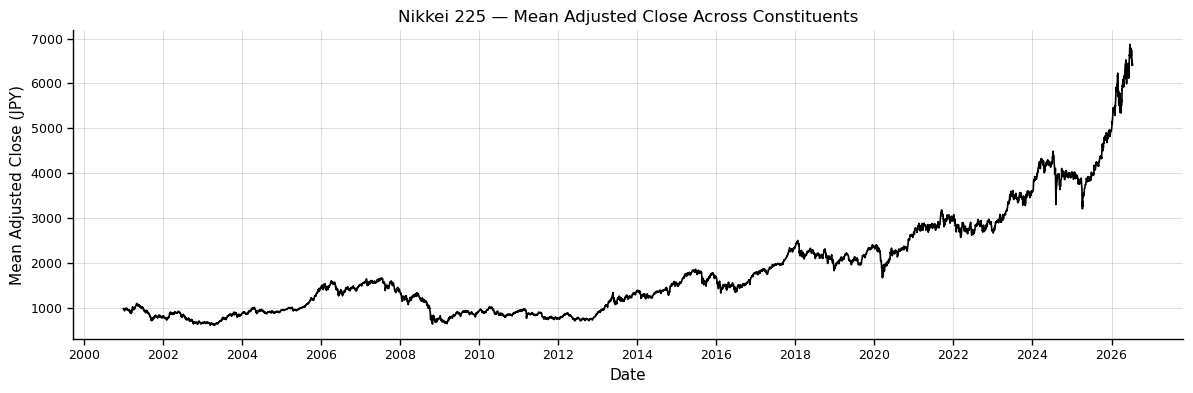

In [26]:
# Mean adjusted close across Nikkei 225 constituents, EPJ-styled.
mean_price = df_clean.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_price.index, mean_price.values, color=NEUTRAL_COLOURS["primary"], linewidth=1.2)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("Nikkei 225 — Mean Adjusted Close Across Constituents")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Adjusted Close (JPY)")
fig.tight_layout()
plt.show()

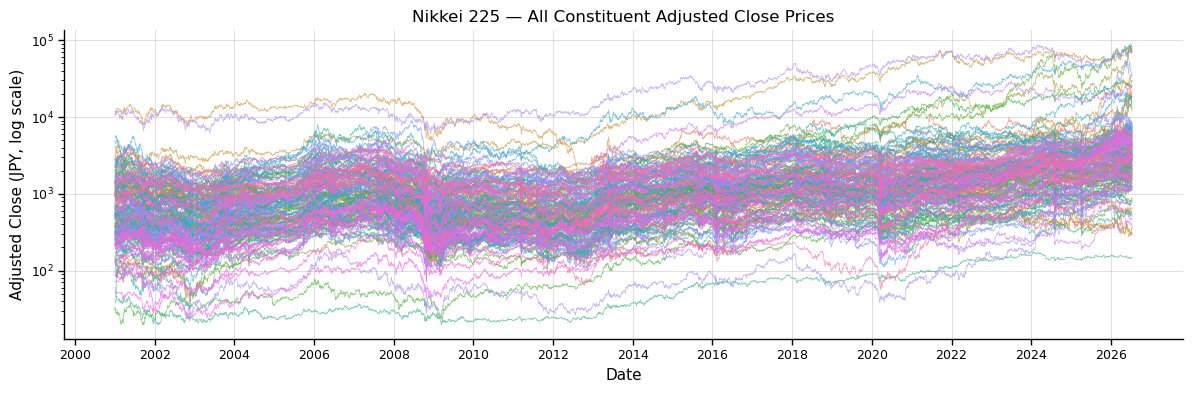

In [27]:
# All individual constituent prices overlaid, EPJ-styled (log scale: raw price levels span orders of magnitude across constituents), one colour per stock.
colours = sns.color_palette("husl", len(df_clean.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(df_clean.index, df_clean.values, alpha=0.6, linewidth=0.5)
ax.set_yscale("log")
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("Nikkei 225 — All Constituent Adjusted Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close (JPY, log scale)")
fig.tight_layout()
plt.show()

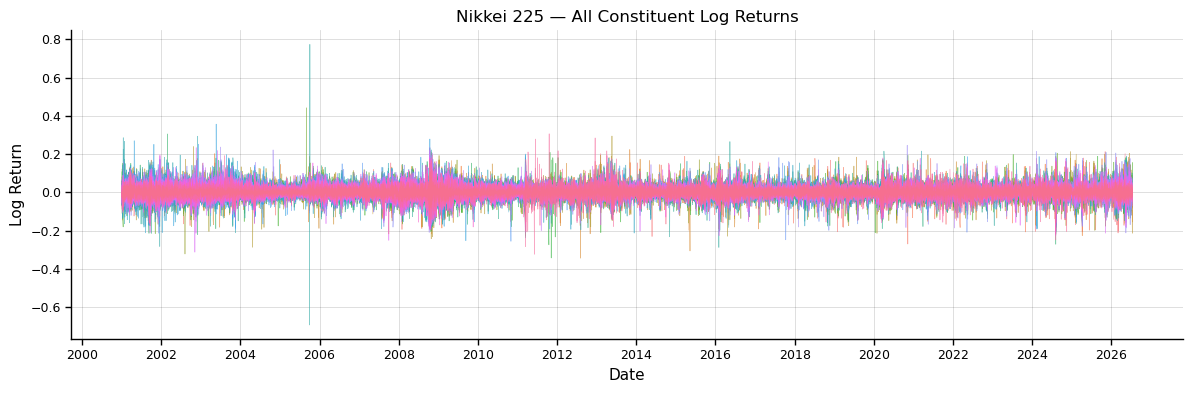

In [28]:
# All individual constituent log returns overlaid, EPJ-styled, one colour per stock.
log_returns = np.log(df_clean).diff()
colours = sns.color_palette("husl", len(log_returns.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(log_returns.index, log_returns.values, alpha=0.6, linewidth=0.5)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("Nikkei 225 — All Constituent Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
fig.tight_layout()
plt.show()

In [29]:
# Raw price series of stocks removed by the prolonged trading halt screen.
df = df_raw.drop(columns=df_raw.columns[(df_raw <= 0).any()])
r = np.log(df).diff()
df = df.drop(columns=r.columns[(r.abs() > 0.8).any()])
df = df.dropna(how="any", axis=1)
r = np.log(df).diff()
flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
df = df.loc[~flat]

HALT_STREAK_DAYS = 63
r = np.log(df).diff()
flat_by_stock = r.abs() < 1e-12
longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
halted_stocks = longest_halt[longest_halt >= HALT_STREAK_DAYS].index

if len(halted_stocks) > 0:
    colours = sns.color_palette("husl", len(halted_stocks))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_prop_cycle(color=colours)
    for stock in halted_stocks:
        ax.plot(df_raw.index, df_raw[stock], alpha=0.8, linewidth=0.8, label=stock)
    style_axis(ax, grid=True)
    format_date_axis(ax, interval_years=2)
    ax.set_title("Nikkei 225 — Raw Prices of Stocks Removed for Prolonged Trading Halts")
    ax.set_xlabel("Date")
    ax.set_ylabel("Adjusted Close (JPY)")
    ax.legend(loc="best", fontsize=7)
    fig.tight_layout()
    plt.show()
else:
    print("No stocks removed for prolonged trading halts.")

No stocks removed for prolonged trading halts.


In [30]:
longest_halt.sort_values(ascending=False).head(10)

MACHIN_6103    40
BANK_8308       7
MACHIN_7004     6
AUTO_7211       6
STEEL_5406      6
ELECMC_6752     5
TRADCO_2768     5
CONSTR_1808     5
BANK_8316       5
RETAIL_3086     4
dtype: int64